In [32]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [33]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import sklearn.metrics as metrics
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST


In [34]:
BATCH_SIZE = 32
device = 'cpu'
transform = transforms.Compose([
    transforms.ToTensor()])
train_data = torchvision.datasets.MNIST(root='data', train=True, download=True, transform=transform,target_transform=None)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,num_workers=0)
test_data = torchvision.datasets.MNIST(root='data', train=False, download=True, transform=transform,target_transform=None)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,num_workers=0)


In [35]:
train_data.data.shape, test_data.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

In [36]:
train_loader.dataset.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [37]:
len(train_data[10])

2

In [38]:
import torch
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch.nn import Linear
from torch_geometric.nn import GCNConv

In [39]:
dataset = KarateClub()
data = dataset[0].to(device)
data
dataset.num_features,dataset.num_classes

(34, 4)

In [40]:
type(dataset),data.edge_index.shape

(torch_geometric.datasets.karate.KarateClub, torch.Size([2, 156]))

In [41]:
import pandas as pd
# Convert node features to a pandas DataFrame
node_features_df = pd.DataFrame(data.x.numpy(), columns=[f'feature_{i}' for i in range(data.x.shape[1])])
node_features_df['node'] = node_features_df.index
node_features_df.set_index('node', inplace=True)

# Convert edge indices to a pandas DataFrame
edge_index_df = pd.DataFrame(data.edge_index.numpy().T, columns=['source', 'target'])

# Convert labels to a pandas DataFrame
labels_df = pd.DataFrame(data.y.numpy(), columns=['label'])
labels_df['node'] = labels_df.index
labels_df.set_index('node', inplace=True)

In [42]:
print(node_features_df)


      feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
node                                                                     
0           1.0        0.0        0.0        0.0        0.0        0.0   
1           0.0        1.0        0.0        0.0        0.0        0.0   
2           0.0        0.0        1.0        0.0        0.0        0.0   
3           0.0        0.0        0.0        1.0        0.0        0.0   
4           0.0        0.0        0.0        0.0        1.0        0.0   
5           0.0        0.0        0.0        0.0        0.0        1.0   
6           0.0        0.0        0.0        0.0        0.0        0.0   
7           0.0        0.0        0.0        0.0        0.0        0.0   
8           0.0        0.0        0.0        0.0        0.0        0.0   
9           0.0        0.0        0.0        0.0        0.0        0.0   
10          0.0        0.0        0.0        0.0        0.0        0.0   
11          0.0        0.0        0.0 

In [43]:
# Print node features DataFrame
print(f"\nNode features (shape: {node_features_df.shape}):")
print(node_features_df.head())  # Print only the first few rows for brevity


Node features (shape: (34, 34)):
      feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
node                                                                     
0           1.0        0.0        0.0        0.0        0.0        0.0   
1           0.0        1.0        0.0        0.0        0.0        0.0   
2           0.0        0.0        1.0        0.0        0.0        0.0   
3           0.0        0.0        0.0        1.0        0.0        0.0   
4           0.0        0.0        0.0        0.0        1.0        0.0   

      feature_6  feature_7  feature_8  feature_9  ...  feature_24  feature_25  \
node                                              ...                           
0           0.0        0.0        0.0        0.0  ...         0.0         0.0   
1           0.0        0.0        0.0        0.0  ...         0.0         0.0   
2           0.0        0.0        0.0        0.0  ...         0.0         0.0   
3           0.0        0.0        0.0     

In [44]:

print(f"\nEdge indices (shape: {edge_index_df.shape}):")
print(edge_index_df)  


Edge indices (shape: (156, 2)):
     source  target
0         0       1
1         0       2
2         0       3
3         0       4
4         0       5
..      ...     ...
151      33      28
152      33      29
153      33      30
154      33      31
155      33      32

[156 rows x 2 columns]


In [45]:
num_countries = 4
np.random.seed(42)
countries = torch.tensor(np.random.choice(num_countries, data.num_nodes))
data.y = countries
print(data.y)

tensor([2, 3, 0, 2, 2, 3, 0, 0, 2, 1, 2, 2, 2, 2, 3, 0, 3, 3, 3, 2, 1, 0, 1, 3,
        3, 1, 1, 1, 3, 3, 0, 0, 3, 1])


In [46]:
data.x.shape, data.edge_index.shape, data.y.shape

(torch.Size([34, 34]), torch.Size([2, 156]), torch.Size([34]))

In [47]:
data.x,data.y

(tensor([[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.]]),
 tensor([2, 3, 0, 2, 2, 3, 0, 0, 2, 1, 2, 2, 2, 2, 3, 0, 3, 3, 3, 2, 1, 0, 1, 3,
         3, 1, 1, 1, 3, 3, 0, 0, 3, 1]))

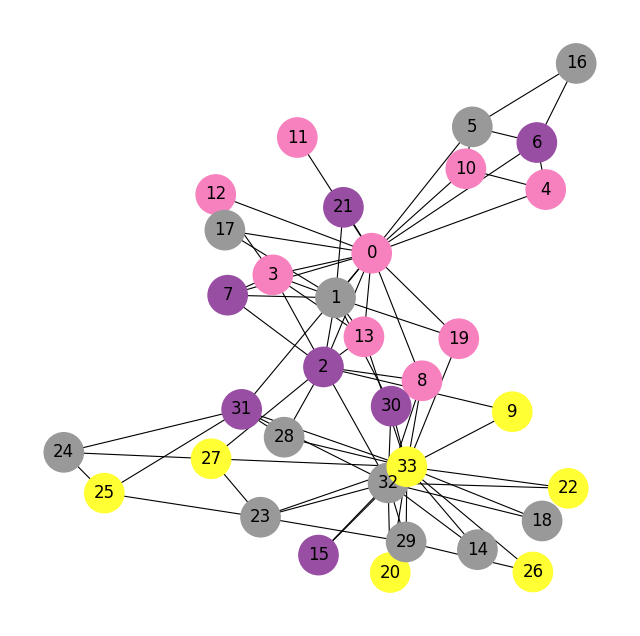

In [48]:
g = to_networkx(data, to_undirected=True)
plt.figure(figsize=(8,8))
plt.axis('off')
nx.draw_networkx(g, pos=nx.spring_layout(g,seed=0),node_size=800,vmin=-2,vmax=3,width=0.8,edge_color='black', with_labels=True, node_color=data.y, cmap='Set1')


In [49]:
from torch.nn import Module

In [50]:
class GCN(Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.middle = Linear(16,16)
        self.relu = nn.ReLU()
        self.conv2 = Linear(16, dataset.num_classes)
    def forward(self,x,edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.middle(h)
        z = self.conv2(h)
        return h,z
model0 = GCN().to(device)
print(model0)

GCN(
  (conv1): GCNConv(34, 16)
  (middle): Linear(in_features=16, out_features=16, bias=True)
  (relu): ReLU()
  (conv2): Linear(in_features=16, out_features=4, bias=True)
)


In [51]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model0.parameters()).values())
unique_params

900

In [52]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model0.parameters(), lr=0.01)


In [53]:
def accuracy(pred_y,y):
    pred_labels = pred_y.argmax(dim=1)
    correct = (pred_labels == y).sum().item()
    total = y.size(0)
    return correct / total

In [54]:
embeddings = []
losses = []
accuracies = []
outputs = []

EPOCHS = 200
for epoch in range(EPOCHS):
    model0.train()
    optimizer.zero_grad()
    h,z = model0(data.x, data.edge_index)
    epoch_loss = criterion(z, data.y)
    acc = accuracy(z, data.y)
    epoch_loss.backward()
    optimizer.step()
    embeddings.append(h.detach().numpy())
    losses.append(epoch_loss.item())
    accuracies.append(acc)
    outputs.append(z.detach().numpy())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss.item():.4f}, Accuracy: {acc:.4f}")

Epoch 0, Loss: 1.4149, Accuracy: 0.2647
Epoch 20, Loss: 0.9551, Accuracy: 0.5588
Epoch 40, Loss: 0.3347, Accuracy: 0.9118
Epoch 60, Loss: 0.0648, Accuracy: 1.0000
Epoch 80, Loss: 0.0116, Accuracy: 1.0000
Epoch 100, Loss: 0.0043, Accuracy: 1.0000
Epoch 120, Loss: 0.0026, Accuracy: 1.0000
Epoch 140, Loss: 0.0018, Accuracy: 1.0000
Epoch 160, Loss: 0.0014, Accuracy: 1.0000
Epoch 180, Loss: 0.0011, Accuracy: 1.0000


In [55]:
model0.state_dict()

OrderedDict([('conv1.bias',
              tensor([0.3781, 0.0276, 0.1220, 0.2716, 0.2969, 0.0988, 0.2252, 0.4195, 0.3979,
                      0.1536, 0.2997, 0.2359, 0.1684, 0.6002, 0.1798, 0.0936])),
             ('conv1.lin.weight',
              tensor([[-8.4653e-01, -5.0954e-01,  5.6318e-01, -4.8088e-02, -8.3352e-01,
                        1.2629e-01, -1.5184e-01,  1.6747e-01, -7.4699e-01,  6.6688e-01,
                       -2.7899e-01, -2.3288e-01, -7.4656e-01, -3.7615e-01,  3.4935e-01,
                       -2.6790e-01, -1.3014e-01,  4.9077e-01,  5.6161e-01, -9.7712e-02,
                        7.0341e-01,  6.2317e-01,  7.9115e-01,  3.5230e-01,  9.0262e-01,
                       -4.0162e-01,  9.1562e-01,  5.8858e-02,  3.4145e-01, -2.9325e-01,
                        4.9257e-01,  2.4651e-01, -6.9873e-01,  3.9617e-01],
                      [-8.3435e-02, -1.1692e+00,  9.7892e-02, -3.6773e-01,  1.1100e-01,
                       -1.6894e-01, -2.6258e-01,  2.2214e-01,  1.4992e-

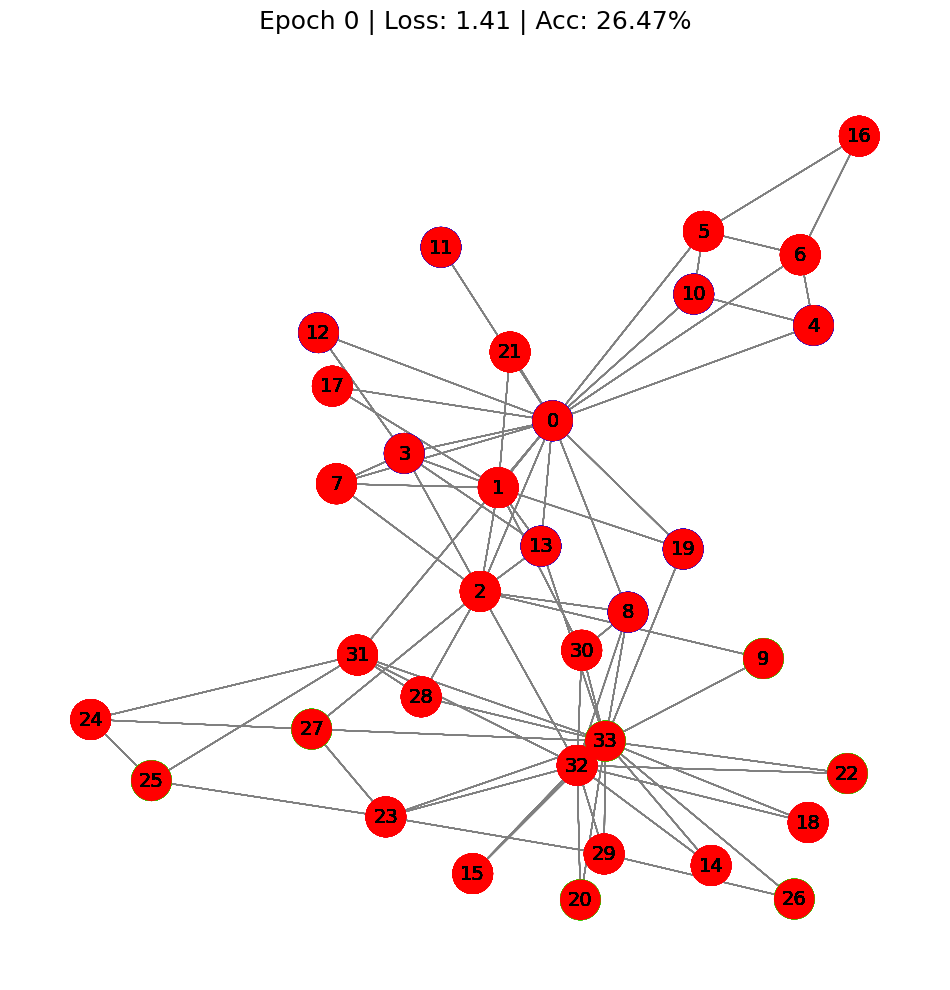

In [56]:
from IPython.display import HTML
from matplotlib import animation

plt.rcParams["animation.bitrate"] = 3000

def animate(i):
    G = to_networkx(data, to_undirected=True)
    normalized_output = torch.softmax(torch.tensor(outputs[i]), dim=1).numpy()
    node_colors = normalized_output.argmax(axis=1)
    
    nx.draw_networkx(G,
                    pos=nx.spring_layout(G, seed=0),
                    with_labels=True,
                    node_size=800,
                    node_color=node_colors,
                    cmap="hsv",
                    width=0.8,
                    edge_color="grey",
                    font_size=14
                    )
    plt.title(f'Epoch {i} | Loss: {losses[i]:.2f} | Acc: {accuracies[i]*100:.2f}%',
              fontsize=18, pad=20)

fig = plt.figure(figsize=(12, 12))
plt.axis('off')
anim = animation.FuncAnimation(fig, animate, np.arange(0, 200, 10), interval=500, repeat=True)
html = HTML(anim.to_jshtml())
display(html)

Final embeddings = torch.Size([34, 16])
tensor([[-3.3377, -1.7406, -2.8193,  0.2897,  1.5190, -2.8118,  3.9119, -0.6197,
          1.6176,  2.0486,  0.8389, -0.6090,  1.7256, -2.1076,  1.8247, -1.5053],
        [-0.9127,  0.5163, -1.2463,  0.1158, -0.4490, -0.2632,  1.9545,  1.0149,
         -0.1382, -0.0959,  0.2234, -1.2699, -0.2031, -0.5914, -0.0224,  0.3740],
        [-0.1253,  1.0048, -0.2141, -1.1085,  0.9130, -0.4804,  0.9475, -0.3925,
          1.1457, -0.7261, -1.2985, -1.9802,  1.0075,  0.5612,  1.1086, -1.1738],
        [-2.1811, -0.9626, -1.8733, -0.0694,  1.7151, -2.1825,  2.7838, -0.8928,
          1.7542,  1.2969,  0.1970, -0.8564,  1.8950, -1.2032,  1.8152, -1.7568],
        [-2.5367, -0.8475, -2.2447, -0.4551,  2.0026, -2.4472,  3.3102, -1.1385,
          2.1562,  1.2637, -0.0278, -1.2915,  2.0605, -1.2763,  2.1252, -2.0433],
        [-1.6974,  0.5920, -2.3400, -0.4500, -0.1424, -0.4100,  2.9633,  0.8624,
         -0.0841,  0.0509,  0.2047, -2.1414,  0.0688, -1.3573,  

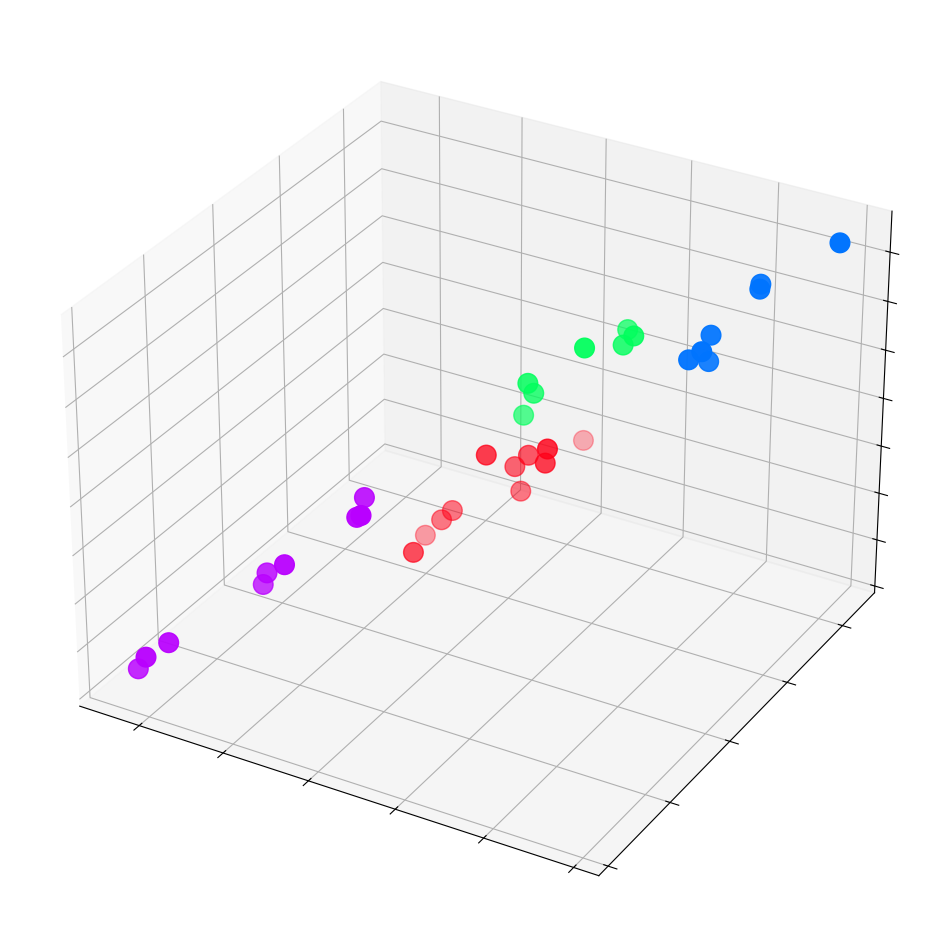

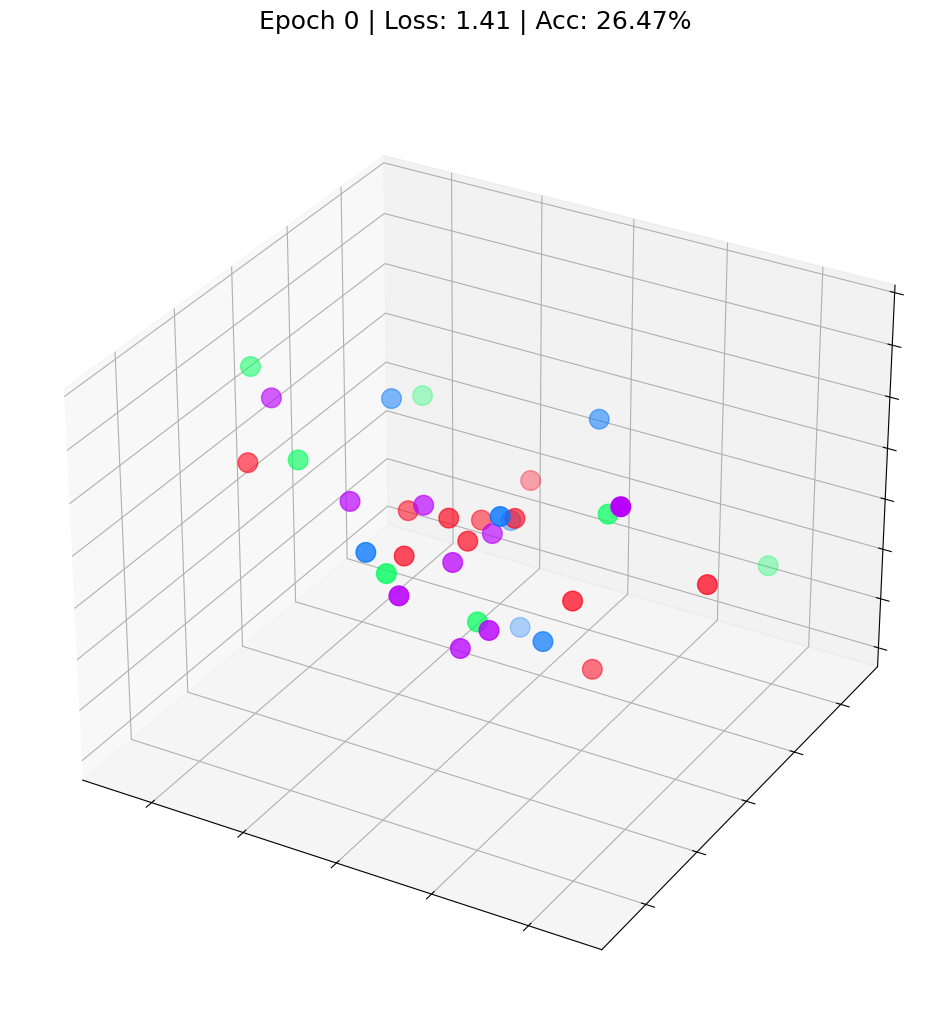

In [57]:

print(f'Final embeddings = {h.shape}')
print(h)

embed = h.detach().cpu().numpy()
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.patch.set_alpha(0)
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.scatter(embed[:, 0], embed[:, 1], embed[:, 2],
           s=200, c=data.y, cmap="hsv", vmin=-2, vmax=3)
plt.show()

def animate_3d(i):
    embed = embeddings[i]
    ax.clear()
    ax.scatter(embed[:, 0], embed[:, 1], embed[:, 2],
               s=200, c=data.y, cmap="hsv", vmin=-2, vmax=3)
    plt.title(f'Epoch {i} | Loss: {losses[i]:.2f} | Acc: {accuracies[i]*100:.2f}%',
              fontsize=18, pad=40)

fig = plt.figure(figsize=(12, 12))
plt.axis('off')
ax = fig.add_subplot(projection='3d')
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
anim = animation.FuncAnimation(fig, animate_3d, np.arange(0, 200, 10), interval=800, repeat=True)
html = HTML(anim.to_jshtml())
display(html)

In [58]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)
MODEL_NAME = "gnn_model.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
torch.save(obj=model0.state_dict(),
            f = MODEL_SAVE_PATH)

